In [104]:
import numpy as np
import matplotlib.pyplot as plt

In [114]:
dset = np.load(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/npz_datasets/soapgpu_ns1275_5000-5050_harps-noise-1.npz"
)

In [115]:
wavegrid = dset["wavegrid"]
spectra = dset["spectra"]
activity = dset["activity"]
template = dset["template"]
v_true = dset["v_true"]
weights_fid = dset["weights_fid"]
for key in dset.keys():
    print(key, dset[key].shape if hasattr(dset[key], "shape") else dset[key])

wavegrid (5001,)
template (5001,)
spectra (1275, 5001)
spectra (1275, 5001)
activity (1275, 5001)
time_values (1275,)
v_true (1275,)
activity (1275, 5001)
time_values (1275,)
v_true (1275,)


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [113]:
%matplotlib qt
plt.figure(figsize=(18, 9))
plt.plot(
    wavegrid,
    spectra[46]
)
plt.plot(wavegrid, weights_fid[46] / weights_fid[46].max())
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.grid()
plt.show()


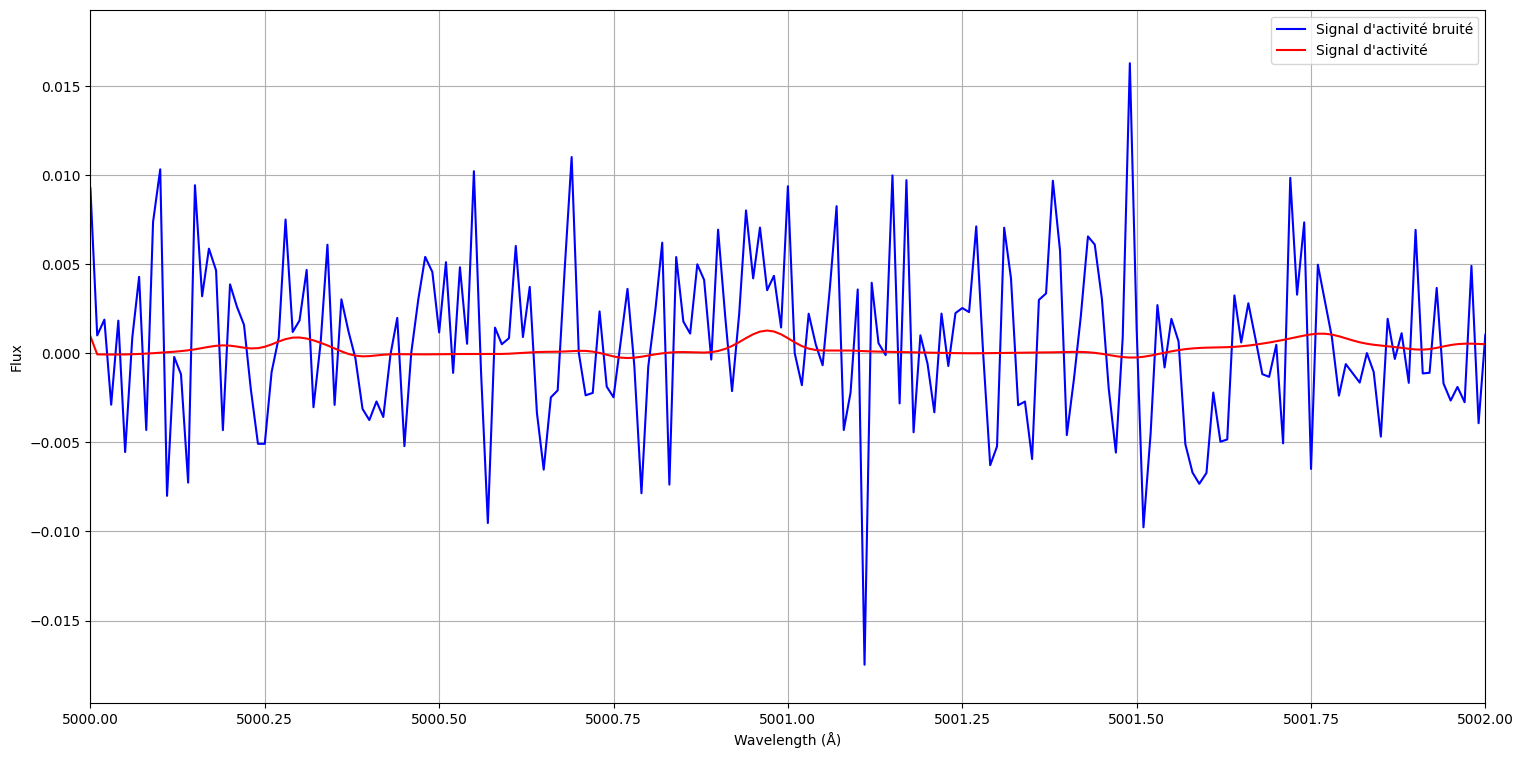

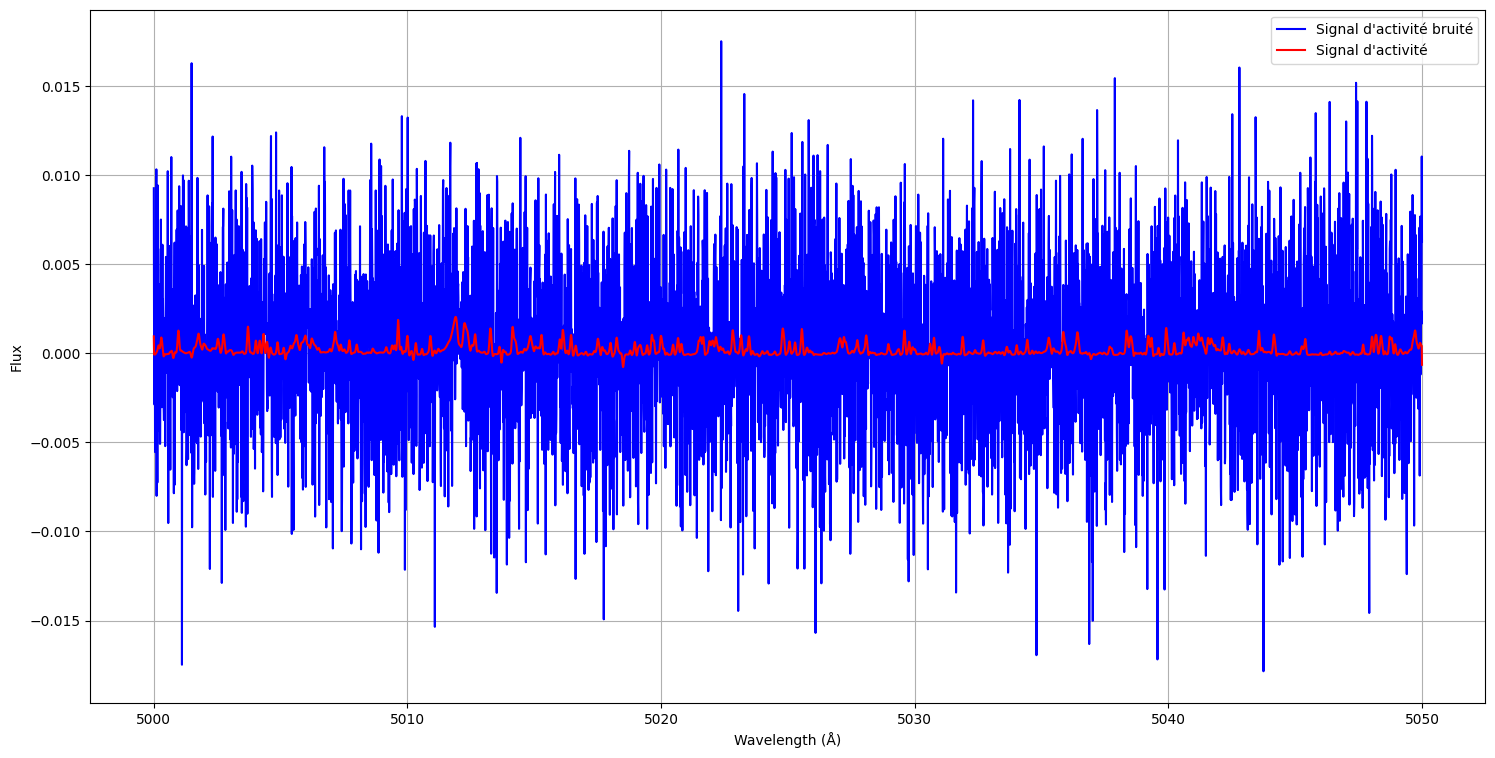

In [108]:
%matplotlib inline
plt.figure(figsize=(18, 9))
plt.plot(wavegrid, spectra[46] - template, label="Signal d'activité bruité", color="blue")
plt.plot(wavegrid, activity[46], label="Signal d'activité", color="red", linestyle="-")
plt.xlabel("Wavelength (Å)")
plt.xlim(5000, 5002)
plt.ylabel("Flux")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(18, 9))
plt.plot(
    wavegrid, spectra[46] - template, label="Signal d'activité bruité", color="blue"
)
plt.plot(wavegrid, activity[46], label="Signal d'activité", color="red", linestyle="-")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.legend()
plt.grid()
plt.show()

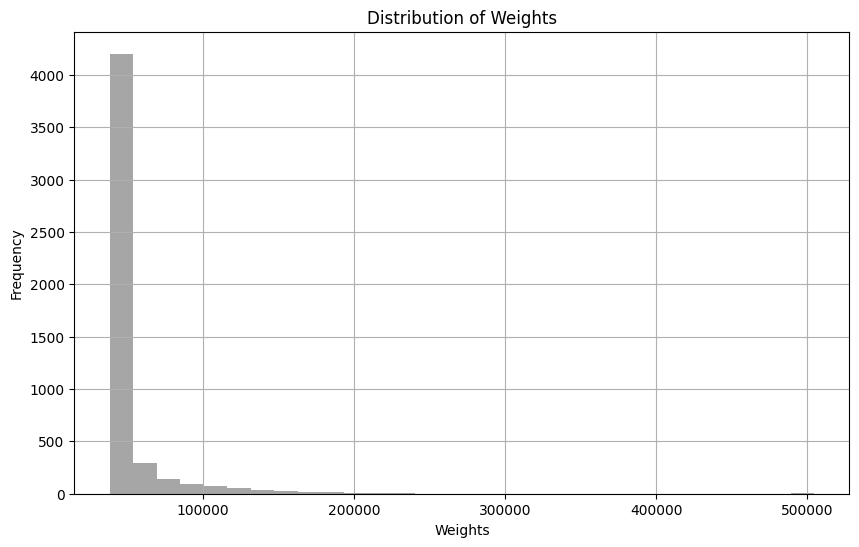

In [109]:
plt.figure(figsize=(10, 6))
plt.hist(weights_fid[0], bins=30, color="gray", alpha=0.7)
plt.xlabel("Weights")
plt.ylabel("Frequency")
plt.title("Distribution of Weights")
plt.grid()
plt.show()

In [110]:
weights_fid

array([[38489.3  , 38396.094, 38297.336, ..., 43256.434, 42908.582,
        42737.44 ],
       [38487.85 , 38394.504, 38295.633, ..., 43265.223, 42917.32 ,
        42746.23 ],
       [38490.53 , 38397.516, 38298.938, ..., 43243.465, 42895.84 ,
        42724.684],
       ...,
       [38491.508, 38398.37 , 38299.645, ..., 43247.066, 42899.664,
        42728.64 ],
       [38489.88 , 38396.758, 38298.164, ..., 43245.14 , 42898.438,
        42727.78 ],
       [38489.496, 38396.305, 38297.637, ..., 43249.098, 42902.37 ,
        42731.81 ]], dtype=float32)

In [116]:
# === TEST DE LA NOUVELLE FONCTIONNALITÉ ACTIVITY_NOISED ===

print("=== TEST DE ACTIVITY_NOISED DANS LE DATASET ===")

# Créer un petit dataset de test avec la nouvelle fonctionnalité
from create_datasets import create_soap_gpu_paper_dataset

try:
    create_soap_gpu_paper_dataset(
        spectra_filepath="/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/soap_equiv_for_harps.h5",
        template_filepath="/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/template.npy",
        wavegrid_filepath="/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/wavegrid.npy",
        new_wavegrid_filepath="/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/new_wavegrid.npy",
        time_values_filepath="/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/time_values_soap_equiv_for_harps.npy",
        output_dir="/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/npz_datasets",
        output_filename="test_activity_noised.npz",
        
        # Configuration spectrale  
        idx_start=0,
        idx_end=50,  # Dataset encore plus petit pour test rapide
        wavemin=5000,
        wavemax=5020,  # Range plus petit pour test
        downscaling_factor=2,  # Pour accélérer
        
        # 🆕 BRUIT RÉALISTE HARPS pour tester activity_noised
        use_realistic_harps_noise=True,
        snr_scaling=1.0,
        noise_seed=42,
        
        # Pas de planète pour ce test
        planets_amplitudes=None,
        planets_periods=None,
        planets_phases=None,
        
        batch_size=25,
        storage_dtype=np.float32,
        compute_ccf_proxies=False,
        interpolate_method="linear",
    )
    
    print("✅ Dataset avec activity_noised créé avec succès!")
    
    # Charger et analyser le nouveau dataset
    dset_test = np.load(
        "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/npz_datasets/test_activity_noised.npz",
        allow_pickle=True
    )
    
    print(f"\n=== ANALYSE DU DATASET AVEC ACTIVITY_NOISED ===")
    print(f"Clés disponibles: {list(dset_test.files)}")
    
    if "activity_noised" in dset_test:
        activity_noised = dset_test["activity_noised"]
        activity_true = dset_test["activity"]
        template = dset_test["template"]
        spectra = dset_test["spectra"]
        
        print(f"\n✅ activity_noised trouvée!")
        print(f"Shape activity_noised: {activity_noised.shape}")
        print(f"Range activity_noised: [{activity_noised.min():.6f}, {activity_noised.max():.6f}]")
        print(f"Range activity_true: [{activity_true.min():.6f}, {activity_true.max():.6f}]")
        
        # Vérifier la cohérence : activity_noised ≈ spectra_bruités - template
        activity_computed = spectra - template.reshape(1, -1)
        diff = np.abs(activity_noised - activity_computed).max()
        print(f"Différence max entre activity_noised et (spectra-template): {diff:.8f}")
        
        if diff < 1e-6:
            print("✅ Cohérence vérifiée: activity_noised = spectra_bruités - template")
        else:
            print("❌ Incohérence détectée!")
        
        # Calculer le niveau de bruit
        noise_in_activity = activity_noised - activity_true
        noise_rms = np.sqrt(np.mean(noise_in_activity**2))
        print(f"RMS du bruit dans l'activité: {noise_rms:.6f}")
        
        # Visualisation comparative
        plt.figure(figsize=(15, 10))
        
        # Plot 1: Comparaison des activités
        plt.subplot(2, 2, 1)
        wavegrid = dset_test["wavegrid"]
        sample_idx = 10
        plt.plot(wavegrid, activity_true[sample_idx], 'k-', label='Activity True', linewidth=2)
        plt.plot(wavegrid, activity_noised[sample_idx], 'r-', label='Activity Noised', alpha=0.7)
        plt.xlabel('Wavelength (Å)')
        plt.ylabel('Activity Flux')
        plt.title(f'Comparaison Activité - Spectre {sample_idx}')
        plt.legend()
        plt.grid()
        
        # Plot 2: Niveau de bruit
        plt.subplot(2, 2, 2)
        noise_spectrum = activity_noised[sample_idx] - activity_true[sample_idx]
        plt.plot(wavegrid, noise_spectrum, 'g-', label='Bruit dans activité')
        plt.axhline(0, color='k', linestyle='--', alpha=0.5)
        plt.xlabel('Wavelength (Å)')
        plt.ylabel('Noise')
        plt.title('Bruit dans le signal d\'activité')
        plt.legend()
        plt.grid()
        
        # Plot 3: Distribution du bruit
        plt.subplot(2, 2, 3)
        plt.hist(noise_in_activity.flatten(), bins=50, alpha=0.7, color='green')
        plt.xlabel('Noise Level')
        plt.ylabel('Frequency')
        plt.title('Distribution du bruit dans l\'activité')
        plt.grid()
        
        # Plot 4: SNR de l'activité
        plt.subplot(2, 2, 4)
        activity_snr = np.abs(activity_true) / (np.abs(noise_in_activity) + 1e-10)
        activity_snr_median = np.median(activity_snr, axis=0)
        plt.plot(wavegrid, activity_snr_median, 'purple', label='SNR médian activité')
        plt.xlabel('Wavelength (Å)')
        plt.ylabel('SNR')
        plt.title('SNR du signal d\'activité')
        plt.legend()
        plt.grid()
        plt.yscale('log')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n🎯 RÉSULTATS:")
        print(f"   ✅ activity_noised implémentée et testée")
        print(f"   ✅ Prête pour être utilisée dans plot_aestra_analysis")
        print(f"   📊 RMS bruit: {noise_rms:.6f}")
        print(f"   📊 SNR médian activité: {np.median(activity_snr):.1f}")
        
    else:
        print("❌ activity_noised non trouvée dans le dataset!")
        print("Vérifiez que le bruit a été appliqué (use_realistic_harps_noise=True)")

except Exception as e:
    print(f"❌ Erreur lors du test: {e}")
    import traceback
    traceback.print_exc()

=== TEST DE ACTIVITY_NOISED DANS LE DATASET ===
🔄 Création du dataset SOAP GPU Paper...
Données chargées: fichier=1275 | sélection=50 spectra
Gamme spectrale: 5000.0 - 5020.0 Å
Interpolated spectra and template on new grid (n_pix=2001)
📐 Downscaling: 4000 → 1000 (factor 2)
🔊 Bruit réaliste HARPS basé sur le RV Data Challenge...
📊 Profil SNR HARPS chargé et normalisé
   SNR HARPS original: [1.1, 1.1], mean=1.1
   SNR final: [198.9, 200.8], mean=200.0
   Poids écrêtés: range [38530.641, 533436.551]
💾 Fichier de sortie créé: /home/tliopis/Codes/exoplanets_llopis_mary_2025/data/npz_datasets/test_activity_noised.npz
   - 50 spectres
   - 1000 pixels spectraux
   - Gamme: 5000.0 - 5020.0 Å
🧹 Nettoyage mémoire terminé
✅ Dataset avec activity_noised créé avec succès!

=== ANALYSE DU DATASET AVEC ACTIVITY_NOISED ===
Clés disponibles: ['wavegrid', 'template', 'spectra', 'activity', 'time_values', 'v_true', 'metadata', 'weights_fid']
❌ activity_noised non trouvée dans le dataset!
Vérifiez que le 